In [1]:
!pip install -q --upgrade diffusers transformers accelerate peft datasets torchao

import torch
import matplotlib.pyplot as plt

from diffusers import  StableDiffusionPipeline
from PIL import Image

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("hugging-face")

login(token)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [14]:
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
lora_id = "homerio/estilo_arquitetura_modernista_brasilia_v4"
device = "cuda"

In [3]:
prompts = ["estilo_arquitetura_modernista_brasilia, visão externa do Congresso Nacional do Brasil com suas duas torres centrais sob um ceu azul do cerrado",
           "estilo_arquitetura_modernista_brasilia, Torre do Pavilhão Naciona com a Bandeira do Brasil tremulando no ceu claro",
           "estilo_arquitetura_modernista_brasilia, visão da Catedral Metropolina de Brasilia sob o ceu azul de Brasilia",
           "estilo_arquitetura_modernista_brasilia, visão a partir do centro de uma praça em uma quadra residencial com seus predios de 4 andares e pilotis livres",
           "estilo_arquitetura_modernista_brasilia, visão da frente Palacio do Planalto com uma escultura na frente",
           "estilo_arquitetura_modernista_brasilia, visão da ponte JK sob um ceu de inverno no cerrado"]

seed = 777

In [10]:
prompts = ["estilo_arquitetura_modernista_brasilia, external view of the National Congress of Brazil with its two central towers under the blue sky of the cerrado",
           "estilo_arquitetura_modernista_brasilia, Tower of the National Pavilion with the Brazilian Flag waving in the clear sky",
           "estilo_arquitetura_modernista_brasilia, view of the Metropolitan Cathedral of Brasília under the blue sky of Brasília",
           "estilo_arquitetura_modernista_brasilia, view from the center of a square in a residential block with its 4‑story buildings and open/free pilotis",
           "estilo_arquitetura_modernista_brasilia, front view of the Palácio do Planalto with a sculpture in front",
           "estilo_arquitetura_modernista_brasilia, view of the JK Bridge under a winter sky in the cerrado"]

seed = 777

In [4]:
def gerar_comparativo(prompts, seed, model_id, lora_id=None):
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)

    if lora_id is not None:
        print(f"Carregando LoRA: {lora_id}")
        pipe.load_lora_weights(lora_id)
    else:
        print("Nenhum LoRA fornecido, usando modelo base puro.")

    imagens = []

    for prompt in prompts:
        generator = torch.Generator(device).manual_seed(seed)
        image = pipe(prompt, generator=generator).images[0]
        imagens.append(image)

    del pipe
    torch.cuda.empty_cache()

    return imagens



In [15]:
print  ("Gerando imgs do modelo base ...")

col_base = gerar_comparativo(prompts, seed, model_id, None)

print  ("Gerando imgs do modelo Lora ...")

col_lora = gerar_comparativo(prompts, seed, model_id, lora_id)



Gerando imgs do modelo base ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Nenhum LoRA fornecido, usando modelo base puro.


...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

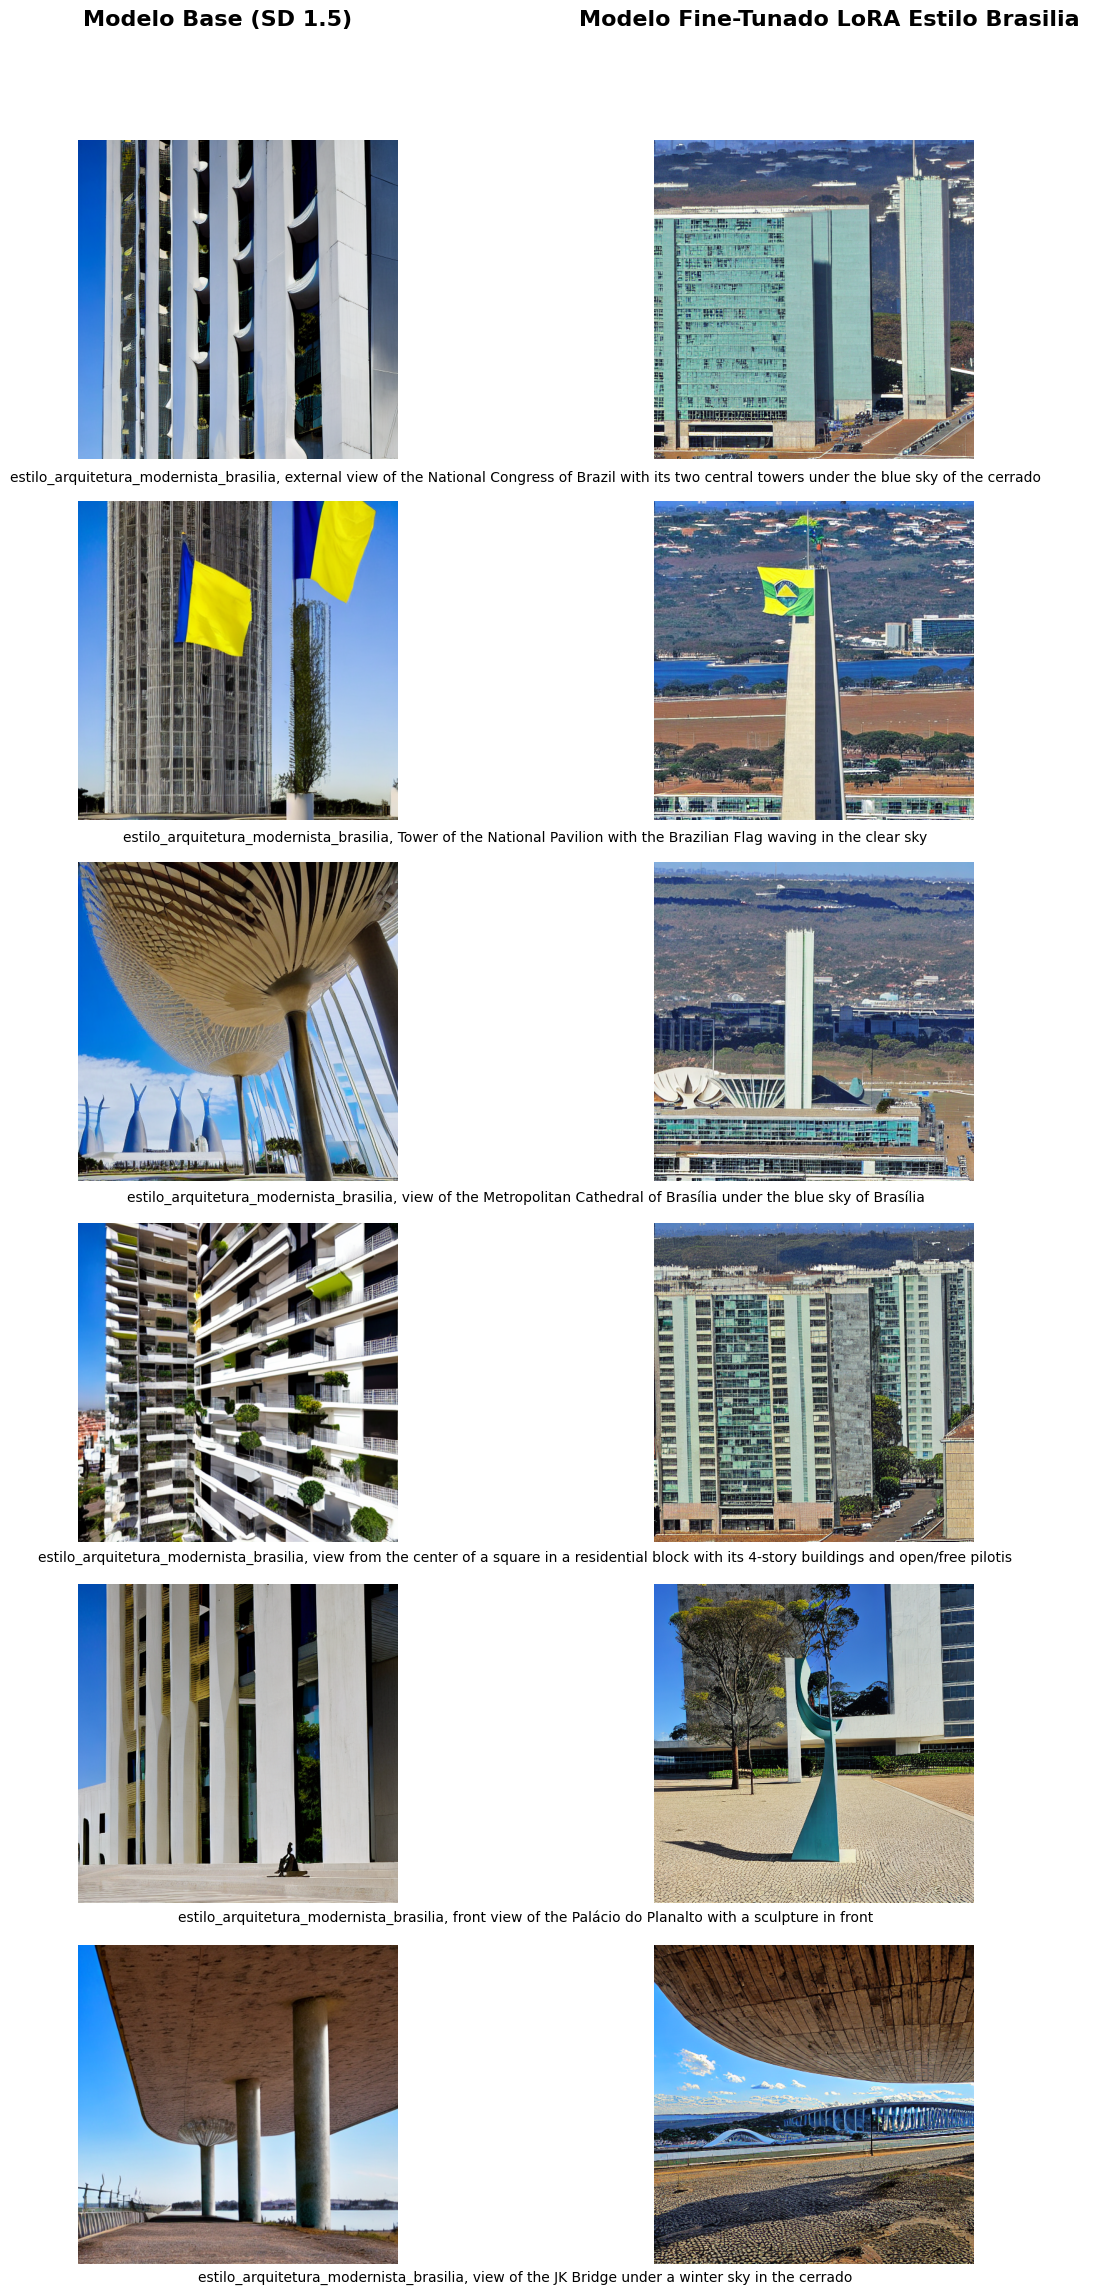

In [17]:
fig, axes = plt.subplots(len(prompts), 2, figsize=(14, 24))

cols = ["Modelo Base (SD 1.5)", "Modelo Fine-Tunado LoRA Estilo Brasilia "]

# fig.subplots_adjust(left=0.3, top=0.95, bottom=0.05)

fig.text(0.28, 0.98, cols[0], ha='center', fontsize=16, fontweight='bold')
fig.text(0.72, 0.98, cols[1], ha='center', fontsize=16, fontweight='bold')


for i in range(len(prompts)):
  axes[i, 0].imshow(col_base[i])
  axes[i, 0].axis("off")
    
  axes[i, 1].imshow(col_lora[i])
  axes[i, 1].axis("off")

  y_pos = 0.94 - (i + 1) * (0.90 / len(prompts))
  fig.text(0.5, y_pos, prompts[i], ha='center', fontsize=10, 
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.subplots_adjust(top=0.92, bottom=0.08)
plt.tight_layout(rect=[0, 0.03, 1, 0.95], pad=3.0)
plt.savefig("comparativo_LoRA.png")
plt.show()

In [21]:
import os
import matplotlib.pyplot as plt

# Cria pasta de saída se não existir
output_dir = "/kaggle/working/lora_saida/individual"
os.makedirs(output_dir, exist_ok=True)

for i, prompt in enumerate(prompts):
    # Salvar imagem do modelo base
    plt.imshow(col_base[i])
    plt.axis("off")
    filename_base = f"{output_dir}/base_{i+1}.png"
    plt.savefig(filename_base, bbox_inches="tight")
    plt.close()

    # Salvar imagem do modelo LoRA
    plt.imshow(col_lora[i])
    plt.axis("off")
    filename_lora = f"{output_dir}/lora_{i+1}.png"
    plt.savefig(filename_lora, bbox_inches="tight")
    plt.close()

print(f"Imagens individuais salvas em {output_dir}")


Imagens individuais salvas em /kaggle/working/lora_saida/individual


In [18]:
!pip -q install torchmetrics 
import torch 
from torchmetrics.multimodal.clip_score import CLIPScore 
  
metrica = CLIPScore(model_name_or_path="openai/clip-vit-base patch16").to("cuda") 
score = metrica(tensor_da_imagem, "estilo_arquitetura_modernista_brasilia, view from the center of a square in a residential block with its 4‑story buildings and open/free pilotis") 
print(f"CLIPScore: {score.item():.2f}") 

OSError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: 'openai/clip-vit-base patch16'.